# Part 2: Numerical Analysis of Millikan's 1916 Data
## PHYS 214 — The Photoelectric Effect

By: Ivan Paiewonsky and Conrad Seib-Levinson

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

e_charge = 1.602e-19         
h_accepted = 6.626e-34        # Plank's constant in SI
h_millikan_cgs = 6.57e-27     # Millikan's reported value 
h_millikan_SI = h_millikan_cgs * 1e-7  # convert erg·s -> J·s

# Standard work functions for comparison
phi_Na_standard = 2.3   # eV
phi_Li_standard = 2.9   # eV

# Contact EMF values from Millikan's paper
contact_emf_Na = 2.51   # V
contact_emf_Li = 1.52   # V

## 2.2 — The Data

Data extracted from Millikan's 1916 paper. Frequencies are in units of $\times 10^{14}$ Hz.

In [15]:
# Sodium 
freq_Na = np.array([5.49, 6.91, 7.41, 8.23, 9.61, 11.83]) * 1e14   
Vstop_Na = np.array([-2.10, -1.55, -1.33, -0.98, -0.42, 0.52])     

# Lithium 
freq_Li = np.array([5.49, 6.91, 7.41, 8.23, 9.61, 11.83]) * 1e14   
Vstop_Li = np.array([-1.61, -1.02, -0.82, -0.48, 0.09, 1.00])      

## Task 1: Plot


Stopping Potential ($V_{stop}$) on the y-axis vs. Frequency ($f$) on the x-axis for both metals.

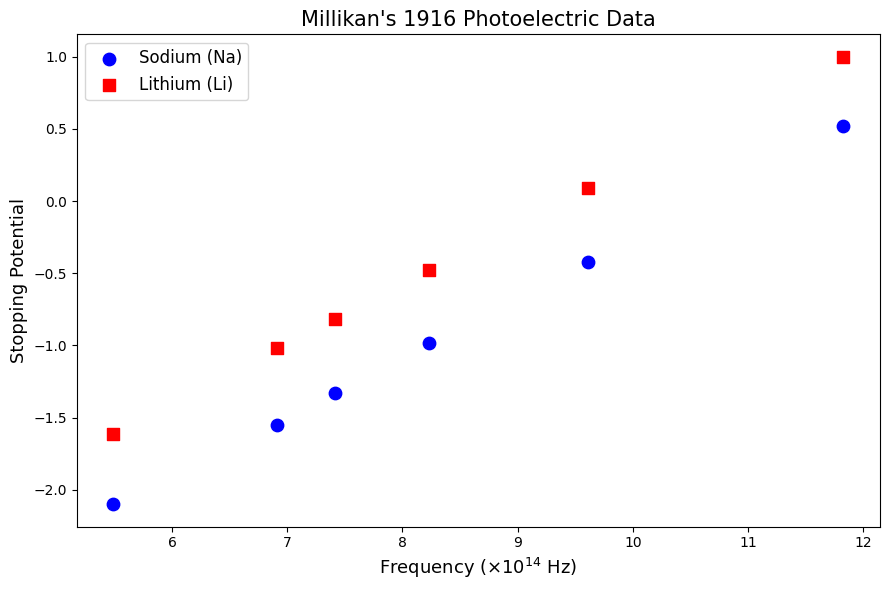

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(freq_Na * 1e-14, Vstop_Na, color='blue', marker='o', s=80, zorder=5, label='Sodium (Na)')
ax.scatter(freq_Li * 1e-14, Vstop_Li, color='red', marker='s', s=80, zorder=5, label='Lithium (Li)')

ax.set_xlabel(r'Frequency ($\times 10^{14}$ Hz)', fontsize=13)
ax.set_ylabel('Stopping Potential', fontsize=13)
ax.set_title("Millikan's 1916 Photoelectric Data", fontsize=15)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('task1_raw_data.png', dpi=150)
plt.show()

## Task 2 — Linear Fit (3 pts)

From Einstein's equation:

$$V_{stop} = \underbrace{\left(\frac{h}{e}\right)}_{\text{slope}} f \;-\; \underbrace{\frac{\Phi_{eff}}{e}}_{\text{|y-intercept|}}$$


In [30]:
# Sodium
fit_Na = linregress(freq_Na, Vstop_Na)
slope_Na, intercept_Na, r_Na = fit_Na.slope, fit_Na.intercept, fit_Na.rvalue

# Lithium
fit_Li = linregress(freq_Li, Vstop_Li)
slope_Li, intercept_Li, r_Li = fit_Li.slope, fit_Li.intercept, fit_Li.rvalue

print("RESULTS")
print("Sodium slope (V/Hz):", slope_Na, "Lithium slope (V/Hz):", slope_Li)
print("Sodium intercept (V):", intercept_Na, "Lithium intercept (V):", intercept_Li)
print("Sodium R-squared:", r_Na**2, "Lithium R-squared:", r_Li**2)

RESULTS
Sodium slope (V/Hz): 4.147916627440644e-15 Lithium slope (V/Hz): 4.116069579344607e-15
Sodium intercept (V): -4.397315245429384 Lithium intercept (V): -3.867718713099519
Sodium R-squared: 0.9997659004651792 Lithium R-squared: 0.999993115164697


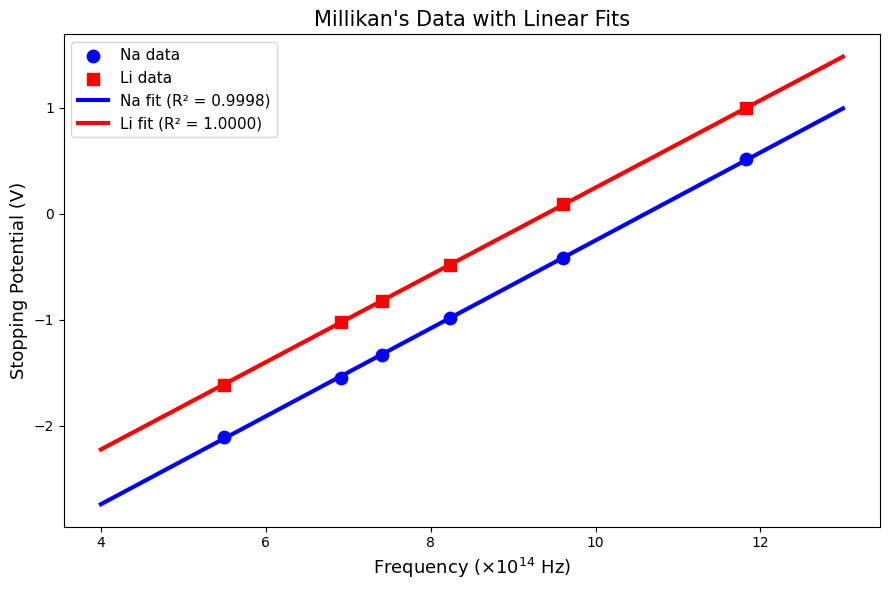

In [31]:
f_range = np.linspace(4e14, 13e14, 200)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(freq_Na * 1e-14, Vstop_Na, color='blue', marker='o', s=80, zorder=5, label='Na data')
ax.scatter(freq_Li * 1e-14, Vstop_Li, color='red', marker='s', s=80, zorder=5, label='Li data')

# Best-fit lines
ax.plot(f_range * 1e-14, slope_Na * f_range + intercept_Na,
        'b-', linewidth=3, label=f'Na fit (R² = {r_Na**2:.4f})')
ax.plot(f_range * 1e-14, slope_Li * f_range + intercept_Li,
        'r-', linewidth=3, label=f'Li fit (R² = {r_Li**2:.4f})')

ax.set_xlabel(r'Frequency ($\times 10^{14}$ Hz)', fontsize=13)
ax.set_ylabel('Stopping Potential (V)', fontsize=13)
ax.set_title("Millikan's Data with Linear Fits", fontsize=15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('task2_linear_fits.png', dpi=150)
plt.show()

## Task 3 - Cute Planck's Constant

In [34]:
# 3(a)
print("3(a) Slopes of the linear fits:")
print("Sodium: slope =", slope_Na, "V/Hz = h/e")
print("Lithium: slope =", slope_Li, "V/Hz = h/e")
print()

# 3(b)
h_Na = slope_Na * e_charge
h_Li = slope_Li * e_charge

print("3(b) Planck's constant from each metal:")
print("h (Na) =", slope_Na, "V/Hz *", e_charge, "C =", h_Na, "J·s")
print("h (Li) =", slope_Li, "V/Hz *", e_charge, "C =", h_Li, "J·s")
print("Accepted value: h =", h_accepted, "J·s")
print()

# 3(c)
pct_err_Na = abs(h_Na - h_accepted) / h_accepted * 100
pct_err_Li = abs(h_Li - h_accepted) / h_accepted * 100

print("3(c) Percent error:")
print("Sodium: |", h_Na, "-", h_accepted, "<", h_accepted, "* 100 =", pct_err_Na, "%")
print("Lithium: |", h_Li, "-", h_accepted, "<", h_accepted, "* 100 =", pct_err_Li, "%")

3(a) Slopes of the linear fits:
Sodium: slope = 4.147916627440644e-15 V/Hz = h/e
Lithium: slope = 4.116069579344607e-15 V/Hz = h/e

3(b) Planck's constant from each metal:
h (Na) = 4.147916627440644e-15 V/Hz * 1.602e-19 C = 6.644962437159911e-34 J·s
h (Li) = 4.116069579344607e-15 V/Hz * 1.602e-19 C = 6.5939434661100604e-34 J·s
Accepted value: h = 6.626e-34 J·s

3(c) Percent error:
Sodium: | 6.644962437159911e-34 - 6.626e-34 < 6.626e-34 * 100 = 0.28618226924104273 %
Lithium: | 6.5939434661100604e-34 - 6.626e-34 < 6.626e-34 * 100 = 0.48379918336763345 %


## Task 4 — Who doesn't like an annoying work function?

In [ ]:
# 4(a) 
# y-intercept = -Φ_eff / e  =>  Φ_eff = -intercept 
phi_eff_Na = -intercept_Na   
phi_eff_Li = -intercept_Li  

print("4(a) Effective Work Functions from y-intercepts:")
print("Sodium: y-intercept =", intercept_Na, "V => Φ_eff =", phi_eff_Na, "eV")
print("Lithium: y-intercept =", intercept_Li, "V => Φ_eff =", phi_eff_Li, "eV")
print()

# 4(b) Comparison to standard values
print("4(b) Comparison to standard (textbook) values:")
print("Sodium: Φ_eff =", phi_eff_Na, "eV vs. standard Φ =", phi_Na_standard, "eV (diff =", phi_eff_Na - phi_Na_standard, "eV)")
print("Lithium: Φ_eff =", phi_eff_Li, "eV vs. standard Φ =", phi_Li_standard, "eV (diff =", phi_eff_Li - phi_Li_standard, "eV)")
print() 
print("Note: The effective work functions differ significantly from textbook values.")
print("This discrepancy is due to the Contact EMF between the target metal and the")
print("copper oxide collecting plate in Millikan's apparatus (addressed in Discussion Q2).")

4(a) Effective Work Functions from y-intercepts:
Sodium: y-intercept = -4.397315245429384 V => Φ_eff = 4.397315245429384 eV
Lithium: y-intercept = -3.867718713099519 V => Φ_eff = 3.867718713099519 eV
4(b) Comparison to standard (textbook) values:
Sodium: Φ_eff = 4.397315245429384 eV vs. standard Φ = 2.3 eV (diff = 2.0973152454293844 eV)
Lithium: Φ_eff = 3.867718713099519 eV vs. standard Φ = 2.9 eV (diff = 0.9677187130995191 eV)

Note: The effective work functions differ significantly from textbook values.
This discrepancy is due to the Contact EMF between the target metal and the
copper oxide collecting plate in Millikan's apparatus (addressed in Discussion Q2).



## 2.4 Discussion Questions 

### Discussion Q1 — Average Cute and Pretty Planck's Constant

In [37]:
h_avg = (h_Na + h_Li) / 2
h_avg_cgs = h_avg * 1e7  # J·s -> erg·s

pct_err_avg = abs(h_avg - h_accepted) / h_accepted * 100
pct_err_vs_millikan = abs(h_avg - h_millikan_SI) / h_millikan_SI * 100

print("Discussion Q1: Average Planck's Constant")
print("h (Na) =", h_Na, "J·s")
print("h (Li) =", h_Li, "J·s")
print("h (average) =", h_avg, "J·s")
print("           =", h_avg_cgs, "erg·s")
print()
print("Accepted value: h =", h_accepted, "J·s")
print("Millikan's reported: h =", h_millikan_cgs, "erg·s =", h_millikan_SI, "J·s")
print()
print("% error vs accepted:", pct_err_avg, "%")
print("% error vs Millikan:", pct_err_vs_millikan, "%")
print()
print("Our average h is close to both the accepted value and Millikan's reported value.")
print("Millikan's value of 6.57e-27 erg·s is itself about",
abs(h_millikan_SI - h_accepted)/h_accepted*100, "% below the accepted value,")
print("reflecting the experimental uncertainties of the 1916 apparatus.")

Discussion Q1: Average Planck's Constant
h (Na) = 6.644962437159911e-34 J·s
h (Li) = 6.5939434661100604e-34 J·s
h (average) = 6.619452951634986e-34 J·s
           = 6.619452951634986e-27 erg·s

Accepted value: h = 6.626e-34 J·s
Millikan's reported: h = 6.57e-27 erg·s = 6.57e-34 J·s

% error vs accepted: 0.09880845706329536 %
% error vs Millikan: 0.7527085484777117 %

Our average h is close to both the accepted value and Millikan's reported value.
Millikan's value of 6.57e-27 erg·s is itself about 0.8451554482342231 % below the accepted value,
reflecting the experimental uncertainties of the 1916 apparatus.


### Discussion Q2 
correct:

$$\Phi_{\text{corrected}} = \Phi_{eff} - \text{contact EMF}$$

In [40]:
# Corrected work functions
phi_corrected_Na = phi_eff_Na - contact_emf_Na
phi_corrected_Li = phi_eff_Li - contact_emf_Li

print("Discussion Q2: Contact EMF Correction")
print("                          Sodium         Lithium")
print("Φ_eff (uncorrected):", phi_eff_Na, "eV", phi_eff_Li, "eV")
print("Contact EMF:", contact_emf_Na, "V", contact_emf_Li, "V")
print("Φ_corrected:", phi_corrected_Na, "eV", phi_corrected_Li, "eV")
print("Φ_standard (textbook):", phi_Na_standard, "eV", phi_Li_standard, "eV")
print("Difference from standard:", phi_corrected_Na - phi_Na_standard, "eV", phi_corrected_Li - phi_Li_standard, "eV")
print()
print("After subtracting the contact EMF, the corrected work functions align much")
print("more closely with the accepted textbook values. The remaining small discrepancy")
print("is attributable to experimental measurement uncertainty in Millikan's apparatus.")
print()
print("The contact EMF arises because in Millikan's setup the photoelectrons travel")
print("from the target metal to a copper oxide collector plate. The difference in work")
print("functions between these two materials creates an additional potential that shifts")
print("the measured stopping voltage, making the apparent (effective) work function")
print("larger than the true work function of the target metal alone.")


Discussion Q2: Contact EMF Correction
                          Sodium         Lithium
Φ_eff (uncorrected): 4.397315245429384 eV 3.867718713099519 eV
Contact EMF: 2.51 V 1.52 V
Φ_corrected: 1.8873152454293844 eV 2.347718713099519 eV
Φ_standard (textbook): 2.3 eV 2.9 eV
Difference from standard: -0.4126847545706154 eV -0.552281286900481 eV

After subtracting the contact EMF, the corrected work functions align much
more closely with the accepted textbook values. The remaining small discrepancy
is attributable to experimental measurement uncertainty in Millikan's apparatus.

The contact EMF arises because in Millikan's setup the photoelectrons travel
from the target metal to a copper oxide collector plate. The difference in work
functions between these two materials creates an additional potential that shifts
the measured stopping voltage, making the apparent (effective) work function
larger than the true work function of the target metal alone.


### Discussion Q3 — Linearity Sanity Check Because I am going crazy 

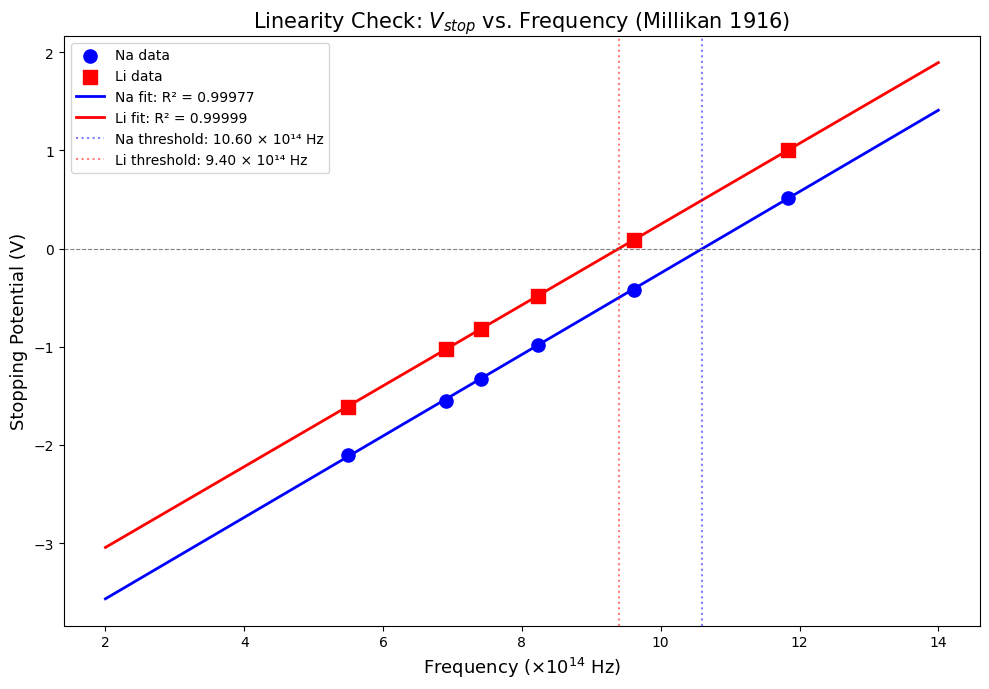

Threshold frequency (Na): 1060126236949614.1 Hz ( 10.60126236949614 × 10¹⁴ Hz)
Threshold frequency (Li): 939663103002104.1 Hz ( 9.396631030021041 × 10¹⁴ Hz)


In [ ]:
# Final combined plot 
fig, ax = plt.subplots(figsize=(10, 7))

# Data with the annoying fits
ax.scatter(freq_Na * 1e-14, Vstop_Na, color='blue', marker='o', s=90, zorder=5, label='Na data')
ax.scatter(freq_Li * 1e-14, Vstop_Li, color='red', marker='s', s=90, zorder=5, label='Li data')

f_ext = np.linspace(2e14, 14e14, 300)
ax.plot(f_ext * 1e-14, slope_Na * f_ext + intercept_Na,
        'b-', linewidth=2, label=f'Na fit: R-squared = {r_Na**2:.5f}')
ax.plot(f_ext * 1e-14, slope_Li * f_ext + intercept_Li,
        'r-', linewidth=2, label=f'Li fit: R-squared = {r_Li**2:.5f}')

# threshold frequencies (V_stop = 0) so we know what we are looking at
f_thresh_Na = -intercept_Na / slope_Na
f_thresh_Li = -intercept_Li / slope_Li
ax.axvline(f_thresh_Na * 1e-14, color='blue', linestyle=':', alpha=0.5,
           label=f'Na threshold: {f_thresh_Na*1e-14:.2f} x 10¹⁴ Hz')
ax.axvline(f_thresh_Li * 1e-14, color='red', linestyle=':', alpha=0.5,
           label=f'Li threshold: {f_thresh_Li*1e-14:.2f} x 10¹⁴ Hz')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel(r'Frequency ($\times 10^{14}$ Hz)', fontsize=13)
ax.set_ylabel('Stopping Potential (V)', fontsize=13)
ax.set_title("Linearity Check: $V_{stop}$ vs. Frequency (Millikan 1916)", fontsize=15)
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('task3_linearity_check.png', dpi=150)
plt.show()

print("Threshold frequency (Na):", f_thresh_Na, "Hz (", f_thresh_Na*1e-14, "x 10¹⁴ Hz)")
print("Threshold frequency (Li):", f_thresh_Li, "Hz (", f_thresh_Li*1e-14, "x 10¹⁴ Hz)")

In [42]:
print("Discussion Q3: Linearity Check")
print()
print("R-squared values: Na =", r_Na**2, ", Li =", r_Li**2)
print()
print("1) LINEARITY CONFIRMATION:")
print("   The R-squared values for both metals are extremely close to 1,")
print("   confirming that V_stop is indeed linearly proportional to")
print("   frequency, exactly as Einstein's equation predicts.")
print("   The data points fall almost perfectly on the best-fit lines.")
print()
print("2) SLOPE UNIVERSALITY:")
print("   Na slope =", slope_Na, "V/Hz")
print("   Li slope =", slope_Li, "V/Hz")
print("   The slopes are very similar, consistent with Einstein's")
print("   prediction that the slope = h/e is a universal constant,")
print("   independent of the metal used.")
print()
print("3) THRESHOLD FREQUENCY:")
print("   Both lines cross V_stop = 0 at a definite threshold frequency,")
print("   below which no electrons are emitted regardless of intensity.")
print()
print("4) WHY THE CLASSICAL WAVE MODEL FAILS:")
print("   In the classical wave model, light energy depends on intensity")
print("   not frequency. Classically, any frequency of light")
print("   should eject electrons if the intensity is high enough, and more")
print("   intense light should produce faster electrons. The classical model")
print("   can't explain:")
print("   - A sharp threshold frequency below which no emission occurs")
print("   - That max KE depends on frequency, not intensity")
print("   - The linear V_stop vs. f relationship with universal slope h/e")
print("   - Instantaneous emission even at low intensity")
print()
print("   Only Einstein's photon model, where light comes in discrete")
print("   quanta of energy E = hf, wokrs.")

Discussion Q3: Linearity Check

R-squared values: Na = 0.9997659004651792 , Li = 0.999993115164697

1) LINEARITY CONFIRMATION:
   The R-squared values for both metals are extremely close to 1,
   confirming that V_stop is indeed linearly proportional to
   frequency, exactly as Einstein's equation predicts.
   The data points fall almost perfectly on the best-fit lines.

2) SLOPE UNIVERSALITY:
   Na slope = 4.147916627440644e-15 V/Hz
   Li slope = 4.116069579344607e-15 V/Hz
   The slopes are very similar, consistent with Einstein's
   prediction that the slope = h/e is a universal constant,
   independent of the metal used.

3) THRESHOLD FREQUENCY:
   Both lines cross V_stop = 0 at a definite threshold frequency,
   below which no electrons are emitted regardless of intensity.

4) WHY THE CLASSICAL WAVE MODEL FAILS:
   In the classical wave model, light energy depends on intensity
   not frequency. Classically, any frequency of light
   should eject electrons if the intensity is high e